In [1]:
#basic imports
import datasets 
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

In [2]:
#load train data
from datasets import load_dataset

In [3]:
train_data = load_dataset("json", data_files="https://huggingface.co/datasets/lzw1008/COLING25-FMD/resolve/main/Training/train.json",split='train')

In [4]:
test_data = load_dataset(
    "json", 
    data_files="https://huggingface.co/datasets/lzw1008/COLING25-FMD/resolve/main/test/FMD_test.json",
    split="train"  
)

In [5]:
train_data

Dataset({
    features: ['ID', 'claim', 'posted', 'sci_digest', 'justification', 'issues', 'image_data', 'label', 'evidence'],
    num_rows: 1953
})

In [6]:
test_data

Dataset({
    features: ['ID', 'claim', 'posted', 'sci_digest', 'justification', 'issues', 'image_data'],
    num_rows: 1304
})

#### samples

In [7]:
train_data[0]

{'ID': 'FMD_train_0',
 'claim': 'Amazon.com and Intifada.com',
 'posted': '09/25/2001',
 'sci_digest': ['Is the web site Intifada.com partnered with Amazon.com?'],
 'justification': 'Claim:  On-line bookseller Amazon.com is partnered with the web site Intifada.com.   Not any more. Example:  [Collected on the Internet, 2001] A good friend of mine, while searching the Internet, ran across Intifada.com. OK. Then he sees a promotion right on their web page by Amazon.Com advising the readers that: "You can buy books about the Intifada and Palestine from Amazon.Com. All profits from the referral will go to developing Intifada.com." How great! I would assume that this pretty well eliminates Amazon.Com as a book seller, for those of us that understand that the Intifada is about killing Israeli civilians and driving Israel out of the land of their forefathers. And obviously Amazon.Com is not planning on receiving any more of our business! It would also be nice for us to notify Amazon.Com of our

### since test data has no labels splitting training data for evaluation

In [8]:
train_data = train_data.train_test_split(test_size=0.3)

In [9]:
train_data

DatasetDict({
    train: Dataset({
        features: ['ID', 'claim', 'posted', 'sci_digest', 'justification', 'issues', 'image_data', 'label', 'evidence'],
        num_rows: 1367
    })
    test: Dataset({
        features: ['ID', 'claim', 'posted', 'sci_digest', 'justification', 'issues', 'image_data', 'label', 'evidence'],
        num_rows: 586
    })
})

In [10]:
train_ds = train_data['train']
test_ds = train_data['test']

In [11]:
train_ds[0]

{'ID': 'FMD_train_1238',
 'claim': 'Is there a photo depicting Ice Cube and 50 Cent wearing hats that support Trump?',
 'posted': '10/20/2020',
 'sci_digest': ['A manipulated image was just a lil bit misleading.'],
 'justification': 'Voting in the 2020 U.S. Election may be over, but misinformation continues to spread. Never stop fact-checking. Follow our post-election coverage here. On Oct. 20, 2020, U.S. President Donald Trump\'s son Eric Trump posted an image to social media that supposedly showed musicians Ice Cube and Curtis "50 Cent" Jackson wearing "Trump 2020" hats. This is not a genuine photograph of 50 Cent and Ice Cube wearing "Trump 2020" hats; it is a doctored image created from a photograph of Ice Cube and 50 Cent at a BIG3 basketball game in Las Vegas, Nevada, in 2017. In the original image, Ice Cube is wearing a hat with the BIG3 logo, while 50 Cent is wearing a hat with a New York Yankees logo. Ice Cube shared the original photograph on his Twitter page in July 2020, al

### keeping only claim+justification+label

In [12]:
train_ds = train_ds.remove_columns(['ID','posted', 'sci_digest', 'issues', 'image_data', 'evidence'])
test_ds = test_ds.remove_columns(['ID','posted', 'sci_digest', 'issues', 'image_data', 'evidence'])

### convert to dataframe

In [13]:
train_df = train_ds.to_pandas()
test_df = test_ds.to_pandas()

In [14]:
train_df

,claim,justification,label
0,Is there a photo depicting Ice Cube and 50 Cen...,"Voting in the 2020 U.S. Election may be over, ...",False
1,Ukraine was the No. 1 donor to Hillary Clinton...,"Rep. Marjorie Taylor Greene, R-Ga., falsely cl...",False
2,FDIC insurance provides payouts for a span exc...,"Claim: After a bank failure, the FDIC has 99 y...",False
3,Is the 'Purse-in-the-Grocery-Cart' Scam Real?,Evaluations of crime and fraud warnings always...,False
4,Did Biden Once Tell Racially Mixed Crowd That ...,"In the early months of 2024, as U.S. President...",True
...,...,...,...
1362,"Since 2001, higher education in the state has ...",As Attorney General Chris Koster eyes the 2016...,True
1363,Did a 1922 Article Warn of Oceans Warming?,One of the key issues in the global warming de...,True
1364,Delaware Child Support Card,"On 8 January 2016, the entertainment web site ...",False
1365,Im the only member of the House of Representat...,A day after a Florida man landed a gyrocopter ...,True


In [15]:
test_df

,claim,justification,label
0,Publix Calendar - Islamic New Year,Claim: A 2010 calendar distributed by Publix ...,True
1,Who is responsible for the increase in debt?,Debt is typically a major campaign issue in el...,True
2,Black Like Ike?,"In 2015, a number of social media posts and em...",NEI
3,"Before I was state treasurer, my Rhode Island ...","In her ""Back To Work"" campaign ad, General Tre...",True
4,Did a Russian Asbestos Company Put Trump's Fac...,"On 25 June 2018, a Russian mining company name...",True
...,...,...,...
581,Scam involving false promises of airline ticke...,Scammers and malware purveyors are always look...,False
582,Your tellers were paid kickbacks for directing...,One of the most heated exchanges between Rick ...,True
583,Hunters contribute more than $500 million to W...,In a tweet that preceded West Virginias buck f...,True
584,We lost more jobs in this great recession than...,"During the April 3, 2011, edition of ABCsThis ...",True


### EDA

Text(0.5, 1.0, 'Train data label distribution')

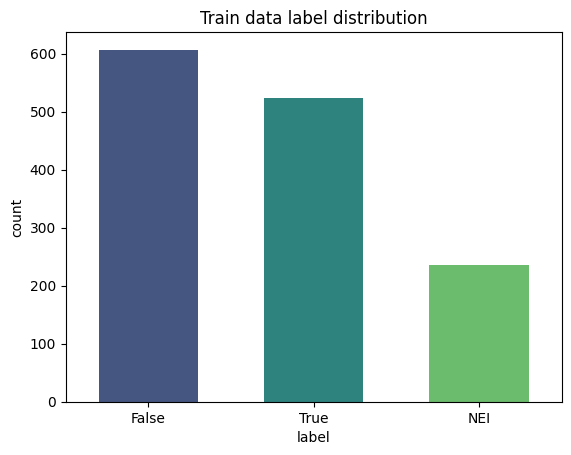

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='label',data=train_df,palette='viridis',width=0.6)
plt.title('Train data label distribution')

Text(0.5, 1.0, 'Test data label distribution')

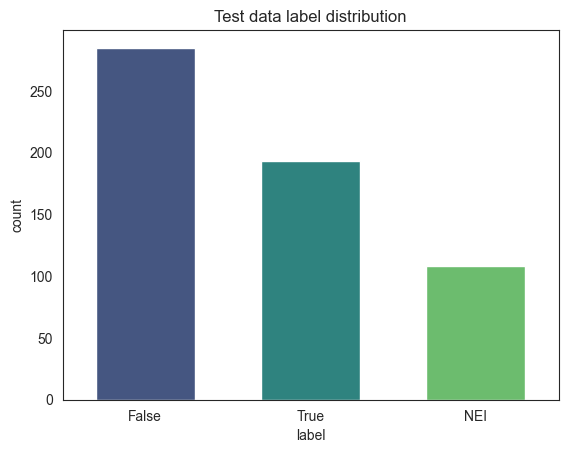

In [42]:
sns.countplot(x='label',data=test_df,palette='viridis',width=0.6,order=['False','True','NEI'])
plt.title('Test data label distribution')

### nearly identical distrbution of labels

### combining text into one column

In [18]:
train_df['text'] = train_df['claim'] + " "+train_df['justification']

In [19]:
test_df['text'] = test_df['claim'] + " " + train_df['justification']

In [20]:
train_df.drop(['claim','justification'],axis=1,inplace=True)
test_df.drop(['claim','justification'],axis=1,inplace=True)

In [21]:
train_df

,label,text
0,False,Is there a photo depicting Ice Cube and 50 Cen...
1,False,Ukraine was the No. 1 donor to Hillary Clinton...
2,False,FDIC insurance provides payouts for a span exc...
3,False,Is the 'Purse-in-the-Grocery-Cart' Scam Real? ...
4,True,Did Biden Once Tell Racially Mixed Crowd That ...
...,...,...
1362,True,"Since 2001, higher education in the state has ..."
1363,True,Did a 1922 Article Warn of Oceans Warming? One...
1364,False,"Delaware Child Support Card On 8 January 2016,..."
1365,True,Im the only member of the House of Representat...


In [22]:
test_df

,label,text
0,True,Publix Calendar - Islamic New Year Voting in t...
1,True,Who is responsible for the increase in debt? R...
2,NEI,"Black Like Ike? Claim: After a bank failure, t..."
3,True,"Before I was state treasurer, my Rhode Island ..."
4,True,Did a Russian Asbestos Company Put Trump's Fac...
...,...,...
581,False,Scam involving false promises of airline ticke...
582,True,Your tellers were paid kickbacks for directing...
583,True,Hunters contribute more than $500 million to W...
584,True,We lost more jobs in this great recession than...


In [23]:
#text length
train_df['text_len'] = train_df['text'].apply(len)

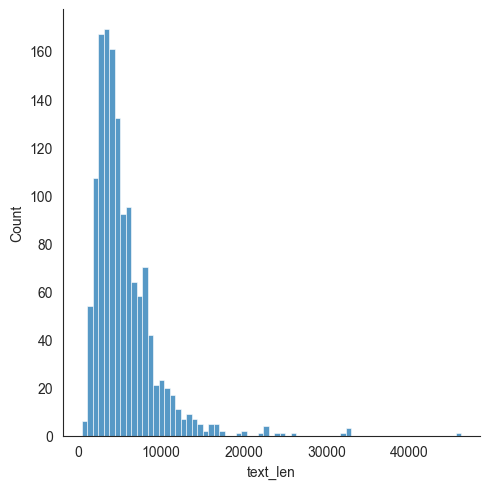

In [24]:
sns.set_style('white')
sns.displot(x='text_len',data=train_df)

In [25]:
train_df['text_len'].quantile(0.95)

11692.600000000006

In [26]:
#restricting text size to 12000
len_ind = list(train_df[train_df['text_len']>=12000].index)
for i in len_ind:
    train_df['text'].loc[i] = train_df['text'].loc[i][:12000]

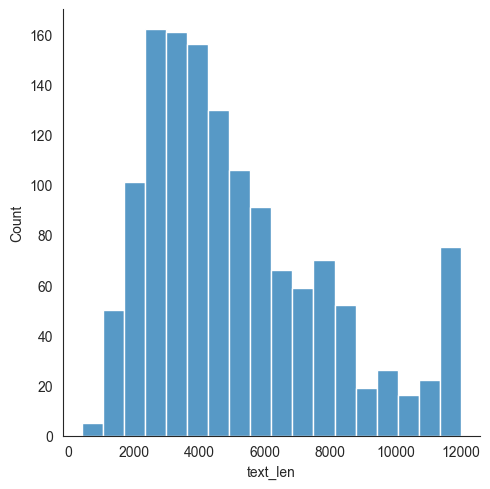

In [27]:
train_df['text_len'] = train_df['text'].apply(len)
sns.set_style('white')
sns.displot(x='text_len',data=train_df)

### cleaning text

In [28]:
import spacy
nlp = spacy.load('en_core_web_sm')
def clean_text(text):
    doc = nlp(text.lower())
    clean_txt = ' '.join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])
    return clean_txt

In [29]:
train_df['cleaned_text'] = train_df['text'].apply(clean_text)

In [30]:
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

### stemming

In [31]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
train_df['cleaned_text'] = train_df['cleaned_text'].apply(lambda x : stemmer.stem(x))
test_df['cleaned_text'] = test_df['cleaned_text'].apply(lambda x : stemmer.stem(x))

In [32]:
train_df

,label,text,text_len,cleaned_text
0,False,Is there a photo depicting Ice Cube and 50 Cen...,2829,photo depict ice cube 50 cent wear hat support...
1,False,Ukraine was the No. 1 donor to Hillary Clinton...,5059,ukraine 1 donor hillary clinton run president ...
2,False,FDIC insurance provides payouts for a span exc...,5301,fdic insurance provide payout span exceed 99 y...
3,False,Is the 'Purse-in-the-Grocery-Cart' Scam Real? ...,3625,purse grocery cart scam real evaluation crime ...
4,True,Did Biden Once Tell Racially Mixed Crowd That ...,11272,biden tell racially mix crowd republicans you ...
...,...,...,...,...
1362,True,"Since 2001, higher education in the state has ...",4458,2001 high education state cut allow erode 35 4...
1363,True,Did a 1922 Article Warn of Oceans Warming? One...,4505,1922 article warn ocean warm key issue global ...
1364,False,"Delaware Child Support Card On 8 January 2016,...",1946,delaware child support card 8 january 2016 ent...
1365,True,Im the only member of the House of Representat...,4553,m member house representative raise campaign f...


In [33]:
test_df

,label,text,cleaned_text
0,True,Publix Calendar - Islamic New Year Voting in t...,publix calendar islamic new year vote 2020 u.s...
1,True,Who is responsible for the increase in debt? R...,responsible increase debt rep marjorie taylor ...
2,NEI,"Black Like Ike? Claim: After a bank failure, t...",black like ike claim bank failure fdic 99 year...
3,True,"Before I was state treasurer, my Rhode Island ...",state treasurer rhode island business help cre...
4,True,Did a Russian Asbestos Company Put Trump's Fac...,russian asbestos company trump face product ea...
...,...,...,...
581,False,Scam involving false promises of airline ticke...,scam involve false promise airline ticket give...
582,True,Your tellers were paid kickbacks for directing...,teller pay kickback direct elderly consumer sa...
583,True,Hunters contribute more than $500 million to W...,hunter contribute $ 500 million west virginia ...
584,True,We lost more jobs in this great recession than...,lose job great recession recession combine c...


### splitting data

In [34]:
X_train = train_df['cleaned_text']
y_train = train_df['label']
X_test = test_df['cleaned_text']
y_test = test_df['label']

### applying tfidf

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=10000)
X_train = tfidf.fit_transform(X_train).toarray()
X_test = tfidf.fit_transform(X_test).toarray()

### training SVM

In [36]:
#create instance of the model
svm = SVC()
#fit model on training data
svm.fit(X_train,y_train)

SVC()

### making predictions

In [37]:
pred_svm = svm.predict(X_test)

### evaluating

In [38]:
from sklearn.metrics import classification_report,confusion_matrix,f1_score,accuracy_score,recall_score,precision_score
print(classification_report(y_test,pred_svm))

              precision    recall  f1-score   support

       False       0.49      0.99      0.65       285
         NEI       0.00      0.00      0.00       108
        True       0.33      0.01      0.02       193

    accuracy                           0.48       586
   macro avg       0.27      0.33      0.22       586
weighted avg       0.35      0.48      0.32       586



Accuracy: 0.48464163822525597
F1 Score: 0.3237303525261098
Recall: 0.48464163822525597
Precision: 0.3462496567415951


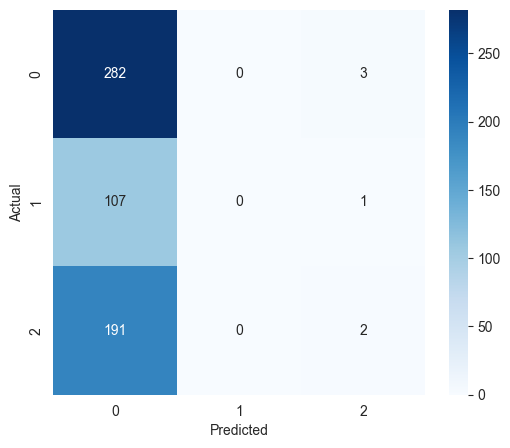

In [39]:
acc = accuracy_score(y_test, pred_svm)
f1 = f1_score(y_test, pred_svm,average='weighted')
recall = recall_score(y_test,pred_svm,average='weighted')
precision = precision_score(y_test,pred_svm,average='weighted')
print("Accuracy:", acc)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:",precision)
cm = confusion_matrix(y_test, pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Random Forest model

In [40]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
pred_rfc = rfc.predict(X_test)
print(classification_report(y_test,pred_rfc))

              precision    recall  f1-score   support

       False       0.48      0.86      0.62       285
         NEI       0.00      0.00      0.00       108
        True       0.36      0.15      0.21       193

    accuracy                           0.47       586
   macro avg       0.28      0.34      0.28       586
weighted avg       0.35      0.47      0.37       586



Accuracy: 0.4658703071672355
F1 Score: 0.3701444496756528
Recall: 0.4658703071672355
Precision: 0.35290398588588473


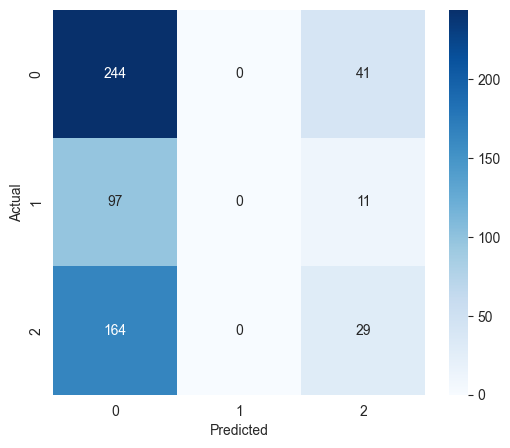

In [41]:
acc = accuracy_score(y_test, pred_rfc)
f1 = f1_score(y_test, pred_rfc,average='weighted')
recall = recall_score(y_test,pred_rfc,average='weighted')
precision = precision_score(y_test,pred_rfc,average='weighted')
print("Accuracy:", acc)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:",precision)
cm = confusion_matrix(y_test, pred_rfc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Infernce : Due to the data being Skewed towards False class and as Tfiidf is not the best text processing methods models achieve low accuracy and F1 of around 50%